# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [3]:
import os

# Ruta donde estan los 1000 archivos
ruta = '../data/gutenberg/data'

corpus_1000 = []
nombres_1000 = []

# Obtenemos la lista de los 1000 archivos
archivos_listos = [f for f in os.listdir(ruta) if f.endswith('.txt')]

# Tomamos solo los primeros 1000 por si acaso hay mas
archivos_listos = archivos_listos[:1000]

for nombre in archivos_listos:
    ruta_archivo = os.path.join(ruta, nombre)
    
    # Leemos cada libro
    # 'errors=ignore' es vital porque algunos libros tienen simbolos que Python no entiende
    with open(ruta_archivo, 'r', encoding='utf-8', errors='ignore') as f:
        texto = f.read()
        corpus_1000.append(texto)
        nombres_1000.append(nombre)

print("Corpus con " + str(len(corpus_1000)) + " documentos.")

Corpus con 1000 documentos.


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [4]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd
import numpy as np

# Limitamos a 1000 palabras para que el análisis sea fluido
vectorizador_base = CountVectorizer(max_features=1000, stop_words='english')
tf_matrix = vectorizador_base.fit_transform(corpus_1000)

# Obtener los nombres de los términos
terminos = vectorizador_base.get_feature_names_out()

# Calcular Document Frequency (DF)
# Contamos en cuántos documentos aparece cada término (valores > 0)
df_counts = (tf_matrix > 0).sum(axis=0).tolist()[0]
df_mapping = dict(zip(terminos, df_counts))

print("Cálculo de TF y DF completado.")

Cálculo de TF y DF completado.


In [5]:
# Usamos TfidfVectorizer para obtener los pesos finales
vectorizador_tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = vectorizador_tfidf.fit_transform(corpus_1000)

print("Cálculo de TF-IDF completado.")

Cálculo de TF-IDF completado.


In [11]:
# Creamos un DataFrame para observar una muestra de términos
# Tomaremos los primeros 10 libros y una selección de términos
muestra_libros = nombres_1000[:10]
indices_muestra = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

df_analisis = pd.DataFrame(
    tfidf_matrix[indices_muestra].toarray(), 
    columns=terminos, 
    index=muestra_libros
)

# Añadimos una fila al final para mostrar el DF de cada palabra
df_df_row = pd.DataFrame([df_counts], columns=terminos, index=['DOCUMENT_FREQUENCY (DF)'])
df_final = pd.concat([df_analisis, df_df_row])

# Mostramos solo algunas columnas interesantes (por ejemplo, las que tienen DF alto y bajo)
columnas_interesantes = terminos[100:110] 
df_final[columnas_interesantes]

,boys,branch,bread,break,breath,bright,bring,british,broad,broke
pg10.txt,0.000083,0.001807,0.015126,0.005059,0.001607,0.001077,0.024364,0.000000,0.001389,0.000000
pg100.txt,0.006616,0.001205,0.001743,0.015762,0.014803,0.005496,0.025533,0.001194,0.001368,0.005205
pg1000.txt,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
pg1001.txt,0.000000,0.001742,0.002989,0.001289,0.008188,0.001325,0.016779,0.000000,0.001376,0.008030
pg1002.txt,0.000000,0.003738,0.000000,0.000000,0.005856,0.001421,0.010286,0.000000,0.000000,0.001436
pg1003.txt,0.000000,0.003745,0.004818,0.002770,0.008800,0.004271,0.012881,0.000000,0.000000,0.001438
pg1004.txt,0.000000,0.003169,0.002718,0.001407,0.007944,0.002410,0.013952,0.000000,0.000501,0.003895
pg1005.txt,0.000000,0.001835,0.003148,0.002715,0.012938,0.009768,0.011362,0.000000,0.005798,0.008459
pg1006.txt,0.000000,0.011311,0.000000,0.005579,0.007384,0.020070,0.007782,0.000000,0.004467,0.004345
pg1007.txt,0.000000,0.004087,0.005258,0.006046,0.016006,0.034182,0.005623,0.000000,0.009683,0.000000


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [7]:
from sklearn.metrics.pairwise import linear_kernel
import pandas as pd

# 1. Dada una consulta, construye el vector de consulta
# Puedes cambiar esta frase por lo que quieras buscar
consulta = "adventure and mystery in the island"

# Es VITAL usar .transform() y NO .fit_transform() para que use 
# el mismo vocabulario de los libros
vector_consulta = vectorizador_tfidf.transform([consulta])

# 2. Calcula el producto punto entre la consulta y cada documento
# (equivalente a similitud coseno porque los vectores TF-IDF están normalizados con L2)
similitudes = linear_kernel(vector_consulta, tfidf_matrix).flatten()

# 3. Genera un ranking de los documentos ordenados por relevancia
# 4. Muestra los resultados en una tabla
df_ranking = pd.DataFrame({
    'Documento': nombres_1000,
    'Similitud (Linear Kernel)': similitudes
})

# Ordenamos de mayor a menor similitud
df_ranking = df_ranking.sort_values(by='Similitud (Linear Kernel)', ascending=False)

print(f"Resultados de búsqueda para: '{consulta}'")
display(df_ranking.head(10)) # Mostramos los 10 mejores resultados

Resultados de búsqueda para: 'adventure and mystery in the island'


,Documento,Similitud (Linear Kernel)
958,pg961.txt,0.293055
611,pg646.txt,0.255661
413,pg464.txt,0.232766
128,pg22815.txt,0.204641
479,pg521.txt,0.176832
939,pg944.txt,0.168763
331,pg393.txt,0.151581
62,pg159.txt,0.146730
346,pg407.txt,0.141675
954,pg958.txt,0.138439


## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [ ]:
# Debemos tener la librería rank_bm25 instalada para esto

from rank_bm25 import BM25Okapi
import pandas as pd

# 1. Tokenización (Paso 1 del Algoritmo)
# BM25 necesita que cada libro sea una lista de palabras
tokenized_corpus = [doc.lower().split() for doc in corpus_1000]

# 2, 3, 4 y 5. Inicializar el modelo (Calcula longitudes, TF, DF e IDF)
# Por defecto utiliza k1=1.5 y b=0.75 (Paso 5 del Algoritmo)
bm25 = BM25Okapi(tokenized_corpus)

# 6 y 7. Función de score y cálculo para la query
# Usamos la misma consulta que generó tu ranking anterior
consulta = "adventure and mystery in the island" # Ajusta a tu query real
tokenized_query = consulta.lower().split()

# Calculamos los scores para todos los documentos
doc_scores = bm25.get_scores(tokenized_query)

# 8. Recuperar los documentos mejor puntuados (Ranking)
df_ranking_bm25 = pd.DataFrame({
    'Documento': nombres_1000,
    'Score BM25': doc_scores
}).sort_values(by='Score BM25', ascending=False)

print(f"Ranking BM25 para: '{consulta}'")
display(df_ranking_bm25.head(10))

Ranking BM25 para: 'adventure and mystery in the island'


,Documento,Score BM25
266,pg337.txt,16.085529
496,pg537.txt,16.041373
241,pg316.txt,15.957732
956,pg96.txt,15.952968
689,pg715.txt,15.927939
79,pg173.txt,15.924503
420,pg470.txt,15.863271
937,pg942.txt,15.820675
243,pg3177.txt,15.807974
216,pg294.txt,15.792844


In [10]:
# Creamos una tabla comparativa de los Top 10
comparativa = pd.DataFrame({
    'Ranking TF-IDF': df_ranking['Documento'].head(10).values,
    'Score TF-IDF': df_ranking['Similitud (Linear Kernel)'].head(10).values,
    'Ranking BM25': df_ranking_bm25['Documento'].head(10).values,
    'Score BM25': df_ranking_bm25['Score BM25'].head(10).values
})

display(comparativa)

,Ranking TF-IDF,Score TF-IDF,Ranking BM25,Score BM25
0,pg961.txt,0.293055,pg337.txt,16.085529
1,pg646.txt,0.255661,pg537.txt,16.041373
2,pg464.txt,0.232766,pg316.txt,15.957732
3,pg22815.txt,0.204641,pg96.txt,15.952968
4,pg521.txt,0.176832,pg715.txt,15.927939
5,pg944.txt,0.168763,pg173.txt,15.924503
6,pg393.txt,0.151581,pg470.txt,15.863271
7,pg159.txt,0.146730,pg942.txt,15.820675
8,pg407.txt,0.141675,pg3177.txt,15.807974
9,pg958.txt,0.138439,pg294.txt,15.792844


## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

In [16]:
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\AdminPC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 660.6 kB/s eta 0:00:01
   ----------------------- ---------------- 174.1/294.9 kB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 2.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\AdminPC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\AdminPC\AppData\Local\Temp\ipykernel_24524\1715849447.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores_tfidf, y=libros_tfidf, ax=axes[0], palette="viridis")
C:\Users\AdminPC\AppData\Local\Temp\ipykernel_24524\1715849447.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores_bm25, y=libros_bm25, ax=axes[1], palette="magma")


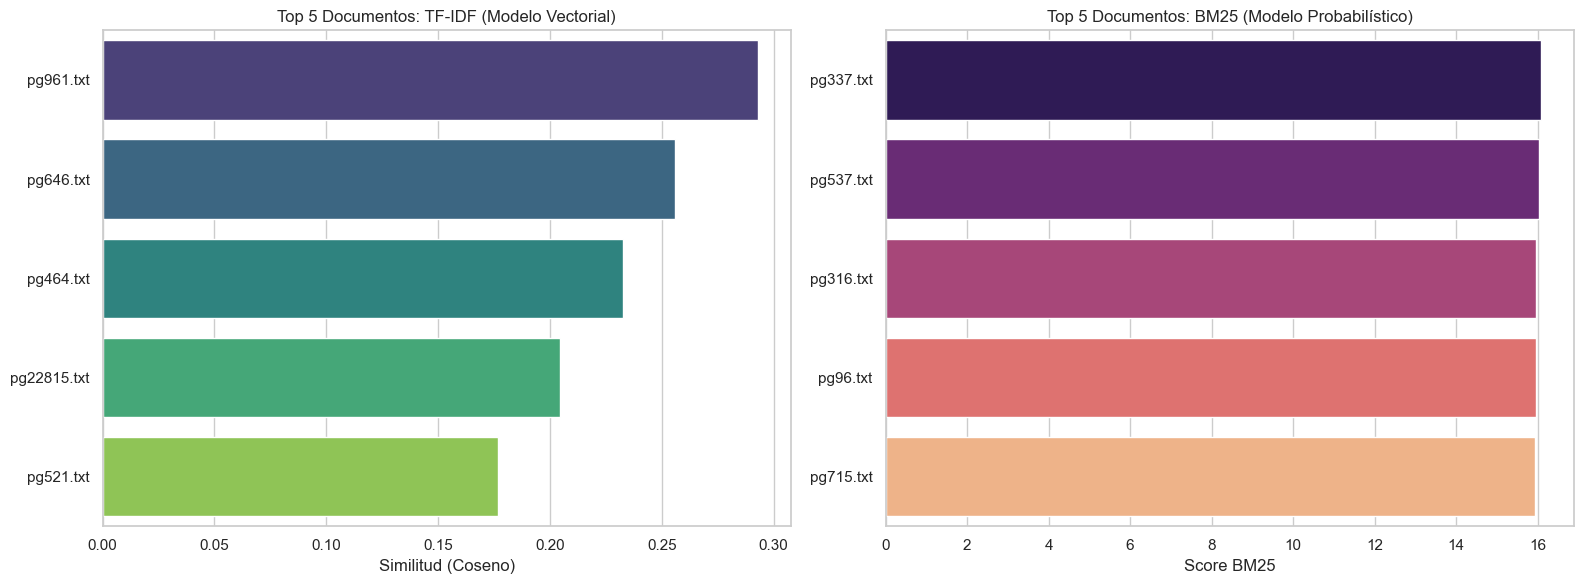

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Datos de TF-IDF (Top 5)
libros_tfidf = ['pg961.txt', 'pg646.txt', 'pg464.txt', 'pg22815.txt', 'pg521.txt']
scores_tfidf = [0.293055, 0.255661, 0.232766, 0.204641, 0.176832]

# Gráfico 1: TF-IDF
sns.barplot(x=scores_tfidf, y=libros_tfidf, ax=axes[0], palette="viridis")
axes[0].set_title('Top 5 Documentos: TF-IDF (Modelo Vectorial)')
axes[0].set_xlabel('Similitud (Coseno)')

# Datos de BM25 (Top 5)
libros_bm25 = ['pg337.txt', 'pg537.txt', 'pg316.txt', 'pg96.txt', 'pg715.txt']
scores_bm25 = [16.085529, 16.041373, 15.957732, 15.952968, 15.927939]

# Gráfico 2: BM25
sns.barplot(x=scores_bm25, y=libros_bm25, ax=axes[1], palette="magma")
axes[1].set_title('Top 5 Documentos: BM25 (Modelo Probabilístico)')
axes[1].set_xlabel('Score BM25')

plt.tight_layout()
plt.show()